# Neural geometry of interaction: solving sudokus by message passing

This notebook demonstrates `discopy.neural`, the compact closed category of
**bidirectional neural networks**:

* objects are *additive* dimensions `Dim(a, b, ...)` — networks compose with
  the cartesian product of vector spaces, so the tensor of dimensions is
  their sum and the unit is the zero-dimensional space `Dim(0)`,
* a box `Network('f', Dim(a), Dim(b), module=...)` carries one torch module
  $\mathbb{R}^{a+b} \to \mathbb{R}^{a+b}$ which reads an incoming message on
  *every* port (domain and codomain alike) and emits an outgoing message on
  every port,
* dimensions are self-dual, so cups, caps and swaps are pure rerouting.

The combinatorial maps of this category are **graph neural networks**: message
passing along the wires implements the *execution formula* of the geometry of
interaction (see Abramsky's *Retracing some paths in process algebra* and
`discopy.interaction` for the Int-construction of Joyal, Street & Verity).

As an experiment, we encode sudoku grids as closed combinatorial maps — one box
per cell, wired to its peers — and train the resulting graph neural network to
solve 4x4 puzzles. Everything is generic in the block size $n$.

In [1]:
import torch
from discopy.neural import *

torch.manual_seed(42)


def mlp(width):
    return torch.nn.Sequential(
        torch.nn.Linear(width, 2 * width), torch.nn.Tanh(),
        torch.nn.Linear(2 * width, width))

The sudoku encoding itself is experiment code rather than library code: a grid is a closed map with one shared cell network wired to its peers, and the helpers below (generation, backtracking solver, checker, decoder) stay with the experiment while `discopy.neural` keeps only the generic categorical machinery.

In [2]:
import random


def sudoku_peers(n: int = 2) -> tuple[tuple[int, ...], ...]:
    """
    The sorted peers of each cell of an ``n ** 2 x n ** 2`` sudoku grid,
    i.e. the cells sharing a row, column or ``n x n`` block with it.

    Parameters:
        n : The size of a block, i.e. 2 for a 4x4 grid, 3 for 9x9.
    """
    size = n * n

    def block(cell):
        return (cell // size // n) * n + (cell % size) // n

    return tuple(
        tuple(sorted(
            other for other in range(size * size) if other != cell and (
                other // size == cell // size
                or other % size == cell % size
                or block(other) == block(cell))))
        for cell in range(size * size))


def sudoku(n: int = 2, dim: int = 2, network: Network = None) -> CMap:
    """
    A sudoku grid encoded as a closed combinatorial map, with one box per
    cell wired to each of its peers.

    Every cell is the same shared :class:`Network` so that the grid has one
    set of weights and does not depend on any given puzzle: the clues are
    injected as initial messages, see :meth:`CMap.forward`.

    Parameters:
        n : The size of a block, i.e. 2 for a 4x4 grid, 3 for 9x9.
        dim : The width of the messages between cells.
        network : The shared cell network,
                  ``Network('cell', Dim(0), Dim(dim) ** len(peers))``
                  by default, with no module.
    """
    peers = sudoku_peers(n)
    network = network if network is not None\
        else Network('cell', Dim(0), Dim(dim) ** len(peers[0]))
    wires = [
        ((cell, peers[cell].index(other)), (other, peers[other].index(cell)))
        for cell in range(n ** 4) for other in peers[cell] if cell < other]
    return CMap.from_wiring(n ** 4 * (network, ), wires)


def solve_sudoku(grid: tuple[int, ...], n: int = 2,
                 digits: tuple[int, ...] = None) -> tuple[int, ...] | None:
    """
    Solve a sudoku grid by backtracking, with 0 for blank cells.

    Parameters:
        grid : The ``n ** 4`` cells of the grid, row-major.
        digits : The order in which to try digits, increasing by default.

    Returns:
        The completed grid, or ``None`` when there is no solution.
    """
    size = n * n
    peers = sudoku_peers(n)
    digits = tuple(range(1, size + 1)) if digits is None else digits
    grid = list(grid)

    def fill(cell):
        if cell == size * size:
            return True
        if grid[cell]:
            return all(grid[peer] != grid[cell] for peer in peers[cell])\
                and fill(cell + 1)
        for digit in digits:
            if all(grid[peer] != digit for peer in peers[cell]):
                grid[cell] = digit
                if fill(cell + 1):
                    return True
        grid[cell] = 0
        return False

    return tuple(grid) if fill(0) else None


def random_sudoku(n: int = 2, n_clues: int = 8, seed: int = 0
                  ) -> tuple[tuple[int, ...], tuple[int, ...]]:
    """
    A random sudoku puzzle and its solution, generated by backtracking with
    a shuffled digit order and then blanking random cells.

    Parameters:
        n : The size of a block, i.e. 2 for a 4x4 grid, 3 for 9x9.
        n_clues : The number of cells left as clues.
        seed : The seed of the random generator.
    """
    size = n * n
    generator = random.Random(seed)
    digits = list(range(1, size + 1))
    generator.shuffle(digits)
    solution = solve_sudoku(size * size * (0, ), n, digits=tuple(digits))
    cells = list(range(size * size))
    generator.shuffle(cells)
    clues = list(solution)
    for cell in cells[:size * size - n_clues]:
        clues[cell] = 0
    return tuple(clues), solution


def check_sudoku(grid: tuple[int, ...], n: int = 2) -> bool:
    """
    Whether a completed grid satisfies all the sudoku constraints.
    """
    size = n * n
    peers = sudoku_peers(n)
    return all(digit in range(1, size + 1) for digit in grid) and all(
        grid[cell] != grid[peer]
        for cell in range(size * size) for peer in peers[cell])


def decode_sudoku(logits, clues: tuple[int, ...],
                  n: int = 2) -> tuple[int, ...]:
    """
    Decode per-cell logits into a completed grid, keeping the clues fixed
    and taking the most likely digit for each blank cell.

    Parameters:
        logits : One row of ``n ** 2`` scores per cell.
        clues : The cells of the puzzle, with 0 for blanks.
    """
    del n
    result = []
    for cell, clue in enumerate(clues):
        if clue:
            result.append(clue)
        else:
            row = list(logits[cell])
            result.append(1 + max(range(len(row)), key=row.__getitem__))
    return tuple(result)

## Bidirectional networks as a compact closed category

Diagrams compose as usual, and the snake equations hold with self-dual
dimensions: transposing the identity yields the identity.

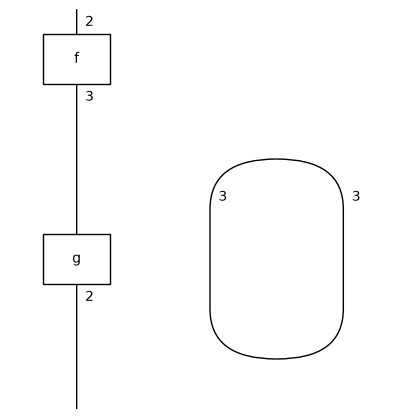

In [3]:
x, y = Dim(2), Dim(3)
f = Network('f', x, y, module=mlp(5))
g = Network('g', y, x, module=mlp(5))

feedback = f @ Cap(y, y) >> g @ Id(y @ y) >> Id(x) @ Cup(y, y)
feedback.draw(figsize=(4, 4))

In [4]:
Diagram.use_hypergraph_equality = True
assert Id(x).transpose() == Id(x) == Id(x).transpose(left=True)
Diagram.use_hypergraph_equality = False

## Message passing is the execution formula

A diagram becomes a combinatorial map with `to_map()`: cups, caps and swaps
dissolve into wiring, only networks remain as boxes. Calling the map runs
synchronous message passing: one message per port, travelling along the wires
each round. For a map with no boxes this is pure rerouting, e.g. the snake
forwards its input unchanged and the swap permutes it.

In [5]:
snake = Id(Dim(2)).transpose().to_map()
assert snake.boxes == ()

point = torch.tensor([[0.1, 0.2]])
assert (snake(point) == point).all()

swap = Diagram.swap(Dim(2), Dim(3)).to_map()
swap(torch.tensor([[1., 2., 3., 4., 5.]]))

tensor([[3., 4., 5., 1., 2.]])

For a map with networks inside, each round every network reads the incoming
messages on all its ports and emits outgoing ones. Boundary inputs are
(re-)delivered every round, so after enough rounds information has crossed
the whole map — this is the trace of the Int-construction, unrolled.

In [6]:
fm = f.to_map()
inputs = torch.rand(1, 2)
assert fm(inputs).shape == (1, 3)

## Sudoku grids as combinatorial maps

A sudoku grid is a *closed* map: one box per cell, one wire between each pair
of *peers* — cells sharing a row, column or block. On a 4x4 grid every cell
has 7 peers, on 9x9 it has 20. All the cells are the same shared `Network`,
so the whole grid has one set of weights and the map itself is
puzzle-independent. Note the graph is highly non-planar.

In [7]:
peers = sudoku_peers(n=2)
cell = Network('cell', Dim(0), Dim(8) ** len(peers[0]),
               module=mlp(8 * len(peers[0])))
grid = sudoku(n=2, network=cell)

print(f"peers of cell 0: {peers[0]}")
print(f"{len(grid.boxes)} cells, {grid.n_ports // 2} wires,"
      f" planar: {grid.is_planar}")
print(f"shared parameters: {sum(p.numel() for p in grid.parameters())}")

peers of cell 0: (1, 2, 3, 4, 5, 8, 12)
16 cells, 56 wires, planar: False
shared parameters: 12712


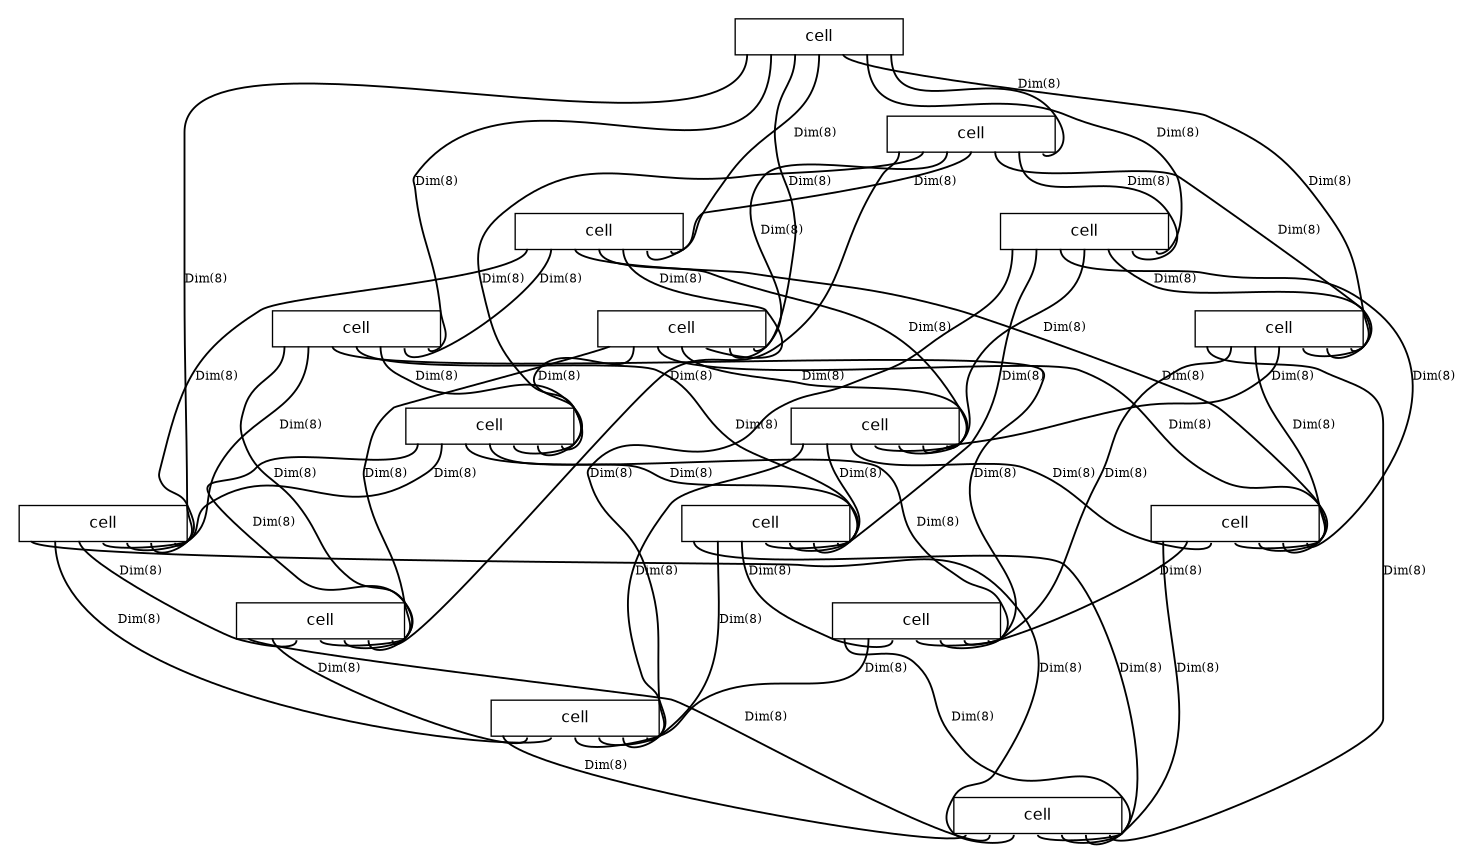

In [8]:
grid.draw()

## From clues to solutions

The clues of a puzzle enter as *initial messages*: each cell's ports start
with a learned embedding of its digit (0 for blank), re-injected at every
round so the clues act as a persistent source. After the last round we read
each cell's state through a linear head, giving one logit per digit.

In [9]:
class SudokuSolver(torch.nn.Module):
    def __init__(self, n=2, dim=8, n_rounds=6):
        super().__init__()
        self.n_rounds = n_rounds
        n_peers = len(sudoku_peers(n)[0])
        self.grid = sudoku(n, network=Network(
            'cell', Dim(0), Dim(dim) ** n_peers, module=mlp(n_peers * dim)))
        self.cells = self.grid.as_network().module
        self.embedding = torch.nn.Embedding(n * n + 1, dim)
        self.readout = torch.nn.Linear(n_peers * dim, n * n)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell in range(clues.shape[1]):
            for port in self.grid.box_ports(cell):
                init[port] = embedded[:, cell, :]
        states = self.cells(init=init, n_rounds=self.n_rounds)
        return self.readout(torch.stack(states, dim=1))


torch.manual_seed(42)
model = SudokuSolver()
sum(p.numel() for p in model.parameters())

12980

## Data

We generate puzzles by backtracking with a shuffled digit order, then blank
random cells. This is a pipeline demo rather than a serious benchmark: 4x4
sudokus only have 288 completed grids, so the point is to watch the graph
neural network learn to propagate constraints, not to compete with solvers.

In [10]:
puzzles = [random_sudoku(n=2, n_clues=8, seed=seed) for seed in range(256)]
train, test = puzzles[:192], puzzles[192:]

clues = torch.tensor([clue for clue, _ in train])
targets = torch.tensor([solution for _, solution in train]) - 1
test_clues = torch.tensor([clue for clue, _ in test])
test_solutions = [solution for _, solution in test]

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []

for step in range(300):
    batch = torch.randint(0, len(train), (32, ))
    optimizer.zero_grad()
    logits = model(clues[batch])
    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, 4), targets[batch].reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

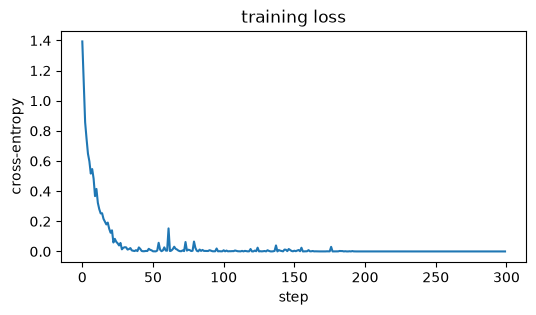

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step"), plt.ylabel("cross-entropy")
plt.title("training loss")
plt.show()

## Decoding

`decode_sudoku` keeps the clues fixed and takes the most likely digit for
each blank cell; `check_sudoku` verifies the result against the rules.

In [13]:
with torch.no_grad():
    logits = model(test_clues)
decoded = [decode_sudoku(logits[i], test[i][0]) for i in range(len(test))]

cell_accuracy = sum(
    digit == expected
    for grid, (_, solution) in zip(decoded, test)
    for digit, expected in zip(grid, solution)) / (16 * len(test))
solved = sum(map(check_sudoku, decoded)) / len(test)
print(f"cell accuracy: {cell_accuracy:.0%}, valid grids: {solved:.0%}")

cell accuracy: 100%, valid grids: 95%


In [14]:
def show(grid):
    return "\n".join(
        " ".join(str(digit) if digit else "." for digit in grid[row:row + 4])
        for row in range(0, 16, 4))

example = next(i for i, grid in enumerate(decoded) if check_sudoku(grid))
print(show(test[example][0]), "\n\n" + show(decoded[example]))

. . . 3
2 3 4 .
. . . .
3 2 1 4 

4 1 2 3
2 3 4 1
1 4 3 2
3 2 1 4


## Does the combinatorial map buy us anything? A vanilla GNN baseline

The map above *is* a graph neural network, but an unusual one. Each cell emits
a **distinct message on every port** — one per peer — and reads its neighbours'
messages port by port; nowhere is there a permutation-invariant pool. This is
exactly what the combinatorial map gives us for free: a rotation system that
addresses every wire individually, and the execution formula routes one message
per port along it.

The workhorse of the GNN literature is *isotropic*: a cell keeps a single hidden
vector, computes **one** shared message from it, and folds its neighbours'
messages together with a permutation-invariant aggregator — sum, mean or max —
before a shared update. The neighbourhood is a set, not a tuple of addressed
ports.

So: does the port structure actually help, or is the combinatorial map just a
baroque way to write a GNN? We hold everything else fixed — the same peer graph,
the same clue injection, the same number of rounds, a **matched parameter
budget** — and swap only the message-passing mechanism.

In [15]:
class VanillaGNN(torch.nn.Module):
    """
    A textbook isotropic message-passing GNN over the sudoku peer graph: one
    hidden vector per cell, a shared message MLP, a permutation-invariant
    aggregator over peers and a shared residual update. Clues are re-injected
    every round, exactly like the combinatorial-map solver.
    """
    def __init__(self, n=2, hidden=36, n_rounds=6, aggr="sum"):
        super().__init__()
        self.n_rounds, self.aggr = n_rounds, aggr
        peers = sudoku_peers(n)
        n_cells = len(peers)
        src = [u for v in range(n_cells) for u in peers[v]]
        dst = [v for v in range(n_cells) for u in peers[v]]
        self.register_buffer("src", torch.tensor(src))
        self.register_buffer("dst", torch.tensor(dst))
        self.embedding = torch.nn.Embedding(n * n + 1, hidden)
        self.message = mlp(hidden)
        self.update = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden, 2 * hidden), torch.nn.Tanh(),
            torch.nn.Linear(2 * hidden, hidden))
        self.readout = torch.nn.Linear(hidden, n * n)

    def forward(self, clues):
        clue_embed = self.embedding(clues)
        h, (B, C, H) = clue_embed, clue_embed.shape
        index = self.dst.view(1, -1, 1).expand(B, -1, H)
        for _ in range(self.n_rounds):
            messages = self.message(h)[:, self.src, :]
            if self.aggr in ("sum", "mean"):
                agg = torch.zeros_like(h).scatter_add(1, index, messages)
                if self.aggr == "mean":
                    agg = agg / (len(self.src) / C)
            else:  # max
                agg = torch.full_like(h, -1e4).scatter_reduce(
                    1, index, messages, reduce="amax", include_self=True)
            h = h + self.update(torch.cat([h, agg], dim=-1))
            h = h + clue_embed  # re-inject the clues, as in the map
        return self.readout(h)

In [16]:
def cmap_solver():
    return SudokuSolver(n=2, dim=8, n_rounds=6)

def n_params(model):
    return sum(p.numel() for p in model.parameters())

def train_solver(make_model, seed, steps=300, lr=0.01, batch=32):
    torch.manual_seed(seed)
    model, opt = make_model(), None
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        idx = torch.randint(0, len(train), (batch, ))
        opt.zero_grad()
        logits = model(clues[idx])
        loss = torch.nn.functional.cross_entropy(
            logits.reshape(-1, 4), targets[idx].reshape(-1))
        loss.backward()
        opt.step()
    return model

def score(model):
    model.eval()
    with torch.no_grad():
        logits = model(test_clues)
    decoded = [decode_sudoku(logits[i], test[i][0]) for i in range(len(test))]
    cell_acc = sum(
        d == e for grid, (_, sol) in zip(decoded, test)
        for d, e in zip(grid, sol)) / (16 * len(test))
    solved = sum(map(check_sudoku, decoded)) / len(test)
    return cell_acc, solved

models = {
    "CMap-GNN\n(port-addressed)": cmap_solver,
    "Vanilla\nsum": lambda: VanillaGNN(hidden=36, aggr="sum"),
    "Vanilla\nmean": lambda: VanillaGNN(hidden=36, aggr="mean"),
    "Vanilla\nmax": lambda: VanillaGNN(hidden=36, aggr="max"),
    "Vanilla sum\n(2.5x params)": lambda: VanillaGNN(hidden=56, aggr="sum"),
}

seeds = range(8)
results = {}
for name, make_model in models.items():
    accs, solves = [], []
    for seed in seeds:
        model = train_solver(make_model, seed)
        cell_acc, solved = score(model)
        accs.append(cell_acc)
        solves.append(solved)
    results[name] = dict(
        params=n_params(make_model()), accs=accs, solves=solves)
    print(f"{name.replace(chr(10), ' '):<28} "
          f"{results[name]['params']:>6} params  "
          f"cell {sum(accs)/len(accs):.3f}  "
          f"solved {sum(solves)/len(solves):.3f}")

CMap-GNN (port-addressed)     12980 params  cell 0.993  solved 0.926


Vanilla sum                   13504 params  cell 0.975  solved 0.924


Vanilla mean                  13504 params  cell 0.975  solved 0.938


Vanilla max                   13504 params  cell 0.980  solved 0.938


Vanilla sum (2.5x params)     32204 params  cell 0.976  solved 0.920


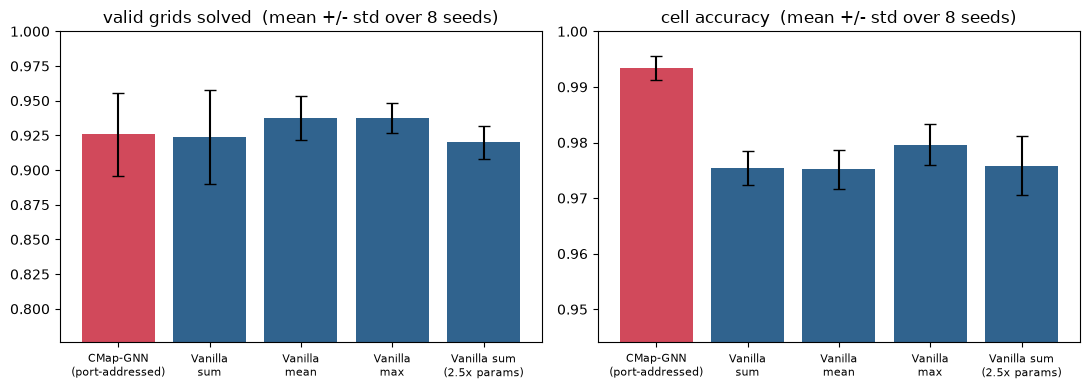

In [17]:
import numpy as np

names = list(results)
solved_mean = [np.mean(results[k]["solves"]) for k in names]
solved_std = [np.std(results[k]["solves"]) for k in names]
acc_mean = [np.mean(results[k]["accs"]) for k in names]
acc_std = [np.std(results[k]["accs"]) for k in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#d1495b"] + ["#30638e"] * (len(names) - 1)
for ax, mean, std, title in [
        (axes[0], solved_mean, solved_std, "valid grids solved"),
        (axes[1], acc_mean, acc_std, "cell accuracy")]:
    ax.bar(range(len(names)), mean, yerr=std, capsize=4, color=colors)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=8)
    ax.set_ylim(min(mean) - 4 * max(std) - 0.01, 1.0)
    ax.set_title(f"{title}  (mean +/- std over {len(list(seeds))} seeds)")
plt.tight_layout()
plt.show()

**A modest but consistent advantage, and not one of capacity.** The
port-addressed map reliably mislabels fewer cells than *any* of the isotropic
aggregators, at a matched parameter budget — and making the vanilla GNN 2.5x
wider does not move it, so the edge is structural rather than a matter of size.
On the harsher *valid-grid* rate, where a single wrong cell fails the whole
puzzle, the gap narrows: the map stays ahead of sum- and max-aggregation but
runs about even with the best-tuned aggregator, mean. So the honest answer is
"yes, a little" — the combinatorial map helps most where the metric rewards
getting each individual constraint right.

Why would port structure help at all? A sudoku constraint is *all-different
among peers*, and the useful message from a peer is "here is the digit I
currently believe". A permutation-invariant sum or mean collapses the seven
incoming beliefs into one vector before the cell can compare them, so the
aggregator has to be inverted before the constraint can be checked — an
information bottleneck. The combinatorial map never pools: every peer keeps its
own wire, the cell sees the seven beliefs side by side, and the rotation system
tells it which belief came from which peer. That is exactly the inductive bias
a constraint-satisfaction graph wants, and it is the same structure — a
distinct message per port, addressed rather than summed — that lets the map
implement the geometry-of-interaction execution formula in the first place.

This is a single small task rather than a benchmark — 4x4 sudoku has only 288
completed grids — so read it as an existence proof, not a leaderboard: message
passing over a combinatorial map does buy something a vanilla GNN does not, by
keeping the wires apart, and the size of that something is a question worth
asking on larger constraint graphs.

## Where to go from here

Nothing above is specific to 4x4 grids: `sudoku(n=3, dim=...)` gives the
81-cell map with 20 ports per cell, and the same solver trains on 9x9
puzzles given more capacity, more rounds and a real dataset. More generally,
`CMap.from_wiring` turns any port-wired collection of `Network` boxes into a
trainable graph neural network, and any `discopy.neural.Diagram` — built
compositionally with cups, caps and swaps — evaluates by message passing
through `to_map()`: string diagrams as neural architectures, with the
geometry of interaction as their operational semantics.